In [59]:
%reload_ext autoreload
%autoreload 2

from fista import LogisticLassoFistaCV
from unlabeled_lr import UnlabeledLogReg
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score

import numpy as np

In [7]:
def generate_high_dim_data(n: int, p: int):
    assert p > 5

    X = np.random.normal(0, 1, size=(n, p))

    beta_true = np.zeros(p)
    true_weights = np.array([2.5, -2.0, 1.5, -1.0, 3.0])
    n_informative = len(true_weights)

    beta_true[:n_informative] = true_weights[:n_informative]

    z = 0.5 + X @ beta_true
    prob = 1 / (1 + np.exp(-z))
    y = np.random.binomial(1, prob)

    return X, y, beta_true

In [4]:
def perform_repeated_holdout(X, y, lambdas, measure: str, n_splits: int, test_size: float=0.3):
    llf = LogisticLassoFistaCV(lambdas, max_iter=50, warm_start=True)

    for i in range(n_splits):
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=i)
    
        llf.fit(X_train, y_train)
        llf.validate(X_val, y_val, measure)
        
        print(f"Finished split [{i+1}/{n_splits}]")
    
    llf.plot(measure)
    llf.plot_coefficients()

    return llf

Finished split [1/30]
Finished split [2/30]
Finished split [3/30]
Finished split [4/30]
Finished split [5/30]
Finished split [6/30]
Finished split [7/30]
Finished split [8/30]
Finished split [9/30]
Finished split [10/30]
Finished split [11/30]
Finished split [12/30]
Finished split [13/30]
Finished split [14/30]
Finished split [15/30]
Finished split [16/30]
Finished split [17/30]
Finished split [18/30]
Finished split [19/30]
Finished split [20/30]
Finished split [21/30]
Finished split [22/30]
Finished split [23/30]
Finished split [24/30]
Finished split [25/30]
Finished split [26/30]
Finished split [27/30]
Finished split [28/30]
Finished split [29/30]
Finished split [30/30]


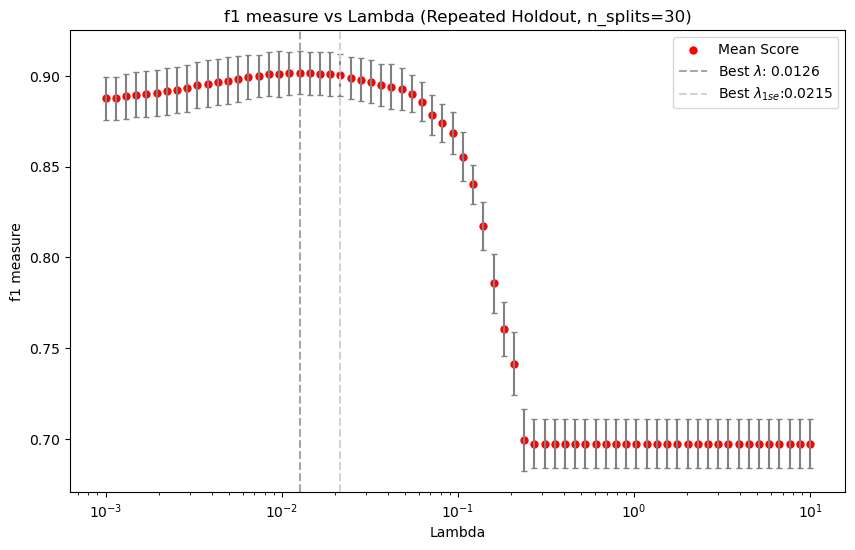

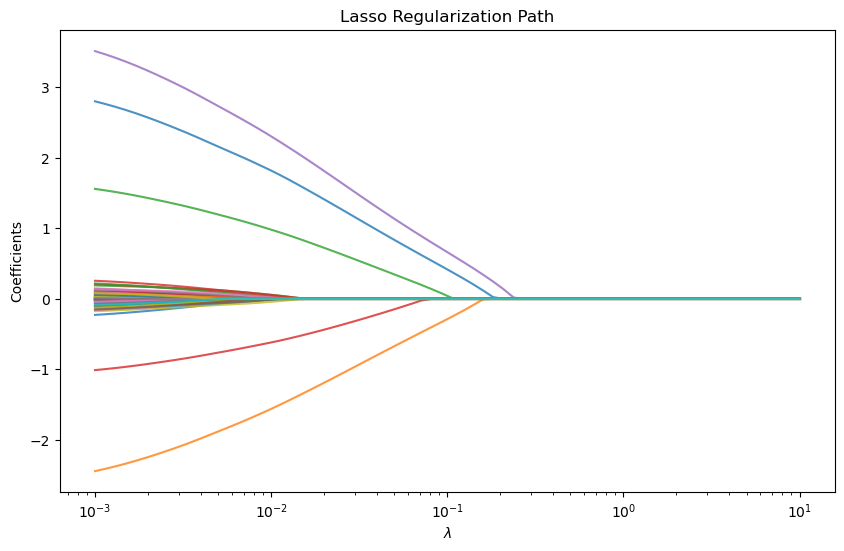

In [9]:
X, y, beta_true = generate_high_dim_data(n=2000, p=100)
    
n_splits = 30
test_size = 0.2
measure = "f1"
lambdas = np.logspace(-3, 1, 70)

llf = perform_repeated_holdout(X, y, lambdas, measure, n_splits, test_size)

In [11]:
from data_prep import ColumnSelector
from unlabeled_lr import UnlabeledLogReg
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from missing import *

In [119]:
X, y, beta_true = generate_high_dim_data(n=2000, p=100)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=10)
pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", ColumnSelector(threshold=0.7)),
    ]
)

ColumnSelector()

pipeline.fit(X_train, y_train)
X_train = pipeline.transform(X_train)
X_val = pipeline.transform(X_val)

In [120]:
y_train = pd.DataFrame(y_train, columns=['class'])

In [133]:
y_train["Y_observed"] = y_train["class"].copy().astype(int)
y_train["S"] = 0
y_train["Missing_Y"] = "no"
y_train_missing = MCAR(y_train, p=0.6)
y_train_missing_one_col = y_train_missing["Y_observed"]

In [134]:
y_train_missing_one_col
mask = y_train_missing_one_col != -1
X_train_lr = X_train[mask]
y_train_lr = y_train[mask]['class']

In [135]:
lr = LogisticRegression(l1_ratio=1, C=1, solver='saga', max_iter=10000)
lr.fit(X_train_lr, y_train_lr)
y_pred = lr.predict(X_val)

In [139]:
ulr = UnlabeledLogReg('iterative_pseudo_labels', imp_prob_threshold=0.8)

ulr.fit(X_train, y_train_missing_one_col)

Discovered 418 new confident y values
Discovered 31 new confident y values
Discovered 9 new confident y values
Discovered 2 new confident y values
Discovered 1 new confident y values
Discovered 0 new confident y values
Ending iterative process. Assigning remaining y with 0.5 threshold...


In [140]:
ulr.validate(X_val, y_val, measure="f1")

(np.float64(0.8790199081163859), np.float64(0.8790199081163859))

In [141]:
print(f1_score(y_val, y_pred))

0.8611544461778471
